In [ ]:
import pandas as pd
df = pd.read_excel("/content/Power BI Updated Data analyst Data.xlsx")

In [ ]:
df.columns

Index(['First Name', 'Email ID', 'Quantity', 'Events', 'Attendee Status',
       'College Name', 'How did you come to know about this event?',
       'Specify in "Others" (how did you come to know about this event)',
       'Designation', 'Year of Graduation', 'City', 'CGPA',
       'Experience with python (Months)', 'Family Income',
       'Expected salary (Lac)', 'Leadership- skills'],
      dtype='object')

In [ ]:
how many unique students are included in the data set?  (there is NO student ID, so the best unique identifier is Email ID)

In [ ]:
unique_students = df['Email ID'].nunique()
print("Number of unique students:", unique_students)


Number of unique students: 2157


what is the avg GPA of the students

In [ ]:
'CGPA' #Check the CGPA column

'CGPA'

In [ ]:
#to Clean the CGPA data
# Convert CGPA to numeric (force errors to NaN)
df['CGPA'] = pd.to_numeric(df['CGPA'], errors='coerce')

In [ ]:
#Calculate Average GPA
avg_gpa = df['CGPA'].mean()
print("Average GPA of students:", round(avg_gpa, 2))

Average GPA of students: 8.04


In [ ]:
#Check missing CGPA values
df['CGPA'].isna().sum()

np.int64(0)

[link text](https://)what is the distribution of students across different graduation years

In [ ]:
'Year of Graduation'

'Year of Graduation'

In [ ]:
#cleaned the data
df['Year of Graduation'] = pd.to_numeric(df['Year of Graduation'], errors='coerce')

In [ ]:
grad_year_distribution = df['Year of Graduation'].value_counts().sort_index()
print(grad_year_distribution)

Year of Graduation
2023    1536
2024    1511
2025    1292
2026     555
Name: count, dtype: int64


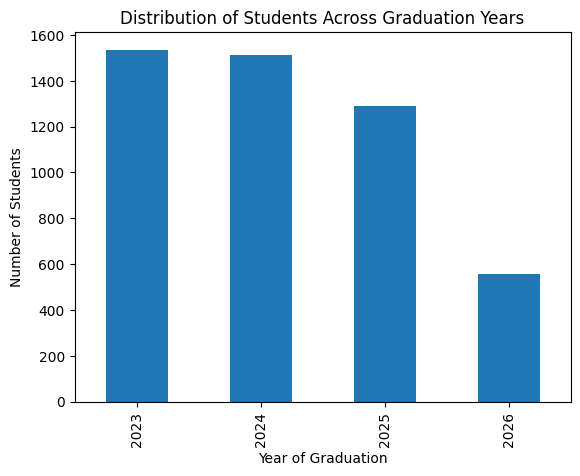

In [ ]:
import matplotlib.pyplot as plt
grad_year_distribution.plot(kind='bar')
plt.xlabel("Year of Graduation")
plt.ylabel("Number of Students")
plt.title("Distribution of Students Across Graduation Years")
plt.show()

what is the distribution of students experience with python programming

In [ ]:
experience_distribution = df['Experience with python (Months)'].value_counts().sort_index()
print(experience_distribution)

Experience with python (Months)
3    1008
4     466
5    1242
6     738
7     640
8     800
Name: count, dtype: int64


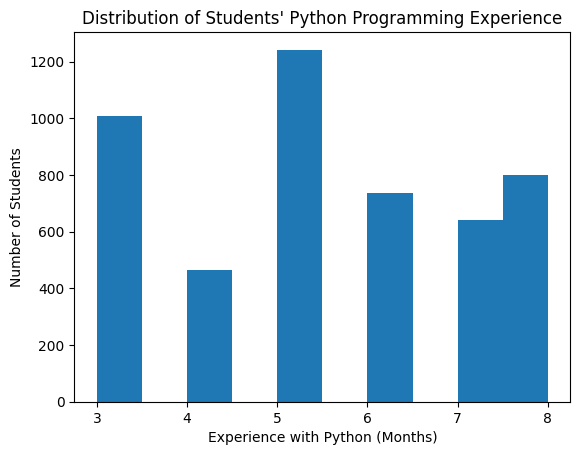

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df['Experience with python (Months)'].dropna(), bins=10)
plt.xlabel("Experience with Python (Months)")
plt.ylabel("Number of Students")
plt.title("Distribution of Students' Python Programming Experience")
plt.show()

In [ ]:
order = [
    'Beginner (0–3)',
    'Basic (4–6)',
    'Intermediate (7–12)',
    'Advanced (12+)'
]

df['Python_Experience_Level'] = pd.Categorical(
    df['Python_Experience_Level'],
    categories=order,
    ordered=True
)

df['Python_Experience_Level'].value_counts().sort_index()


,count
Python_Experience_Level,
Beginner (0–3),1008
Basic (4–6),2446
Intermediate (7–12),1440
Advanced (12+),0


what is the avg of family income of the student

In [ ]:
import pandas as pd
df = pd.read_excel("/content/Power BI Updated Data analyst Data.xlsx")

In [ ]:
income_mapping = {
    "0-2 Lakh": 1,
    "2-5 Lakh": 3.5,
    "5-7 Lakh": 6,
    "7 Lakh+": 8
}

df["Family_Income_Numeric"] = df["Family Income"].map(income_mapping)

In [ ]:
df["Family Income"].value_counts()

,count
Family Income,
0-2 Lakh,4525
2-5 Lakh,200
7 Lakh+,89
5-7 Lakh,80


In [ ]:
average_income = df["Family_Income_Numeric"].mean()
average_income

np.float64(1.3111973845525133)

How does the GPA vary among different colleges? (Top 5 results only)



In [ ]:
import pandas as pd

In [ ]:
college_gpa = (
    df.groupby("College Name")["CGPA"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
)

college_gpa


,CGPA
College Name,
"THAKUR INSTITUTE OF MANAGEMENT STUDIES, CAREER DEVELOPMENT & RESEARCH - [TIMSCDR]",8.585714
St Xavier's College,8.578571
"B. K. Birla College of Arts, Science & Commerce (Autonomous), Kalyan",8.456410
"Symbiosis Institute of Technology, Pune",8.303448
AP SHAH INSTITUTE OF TECHNOLOGY,8.283333


<Axes: title={'center': 'Top 5 Colleges by Average GPA'}, xlabel='College Name'>

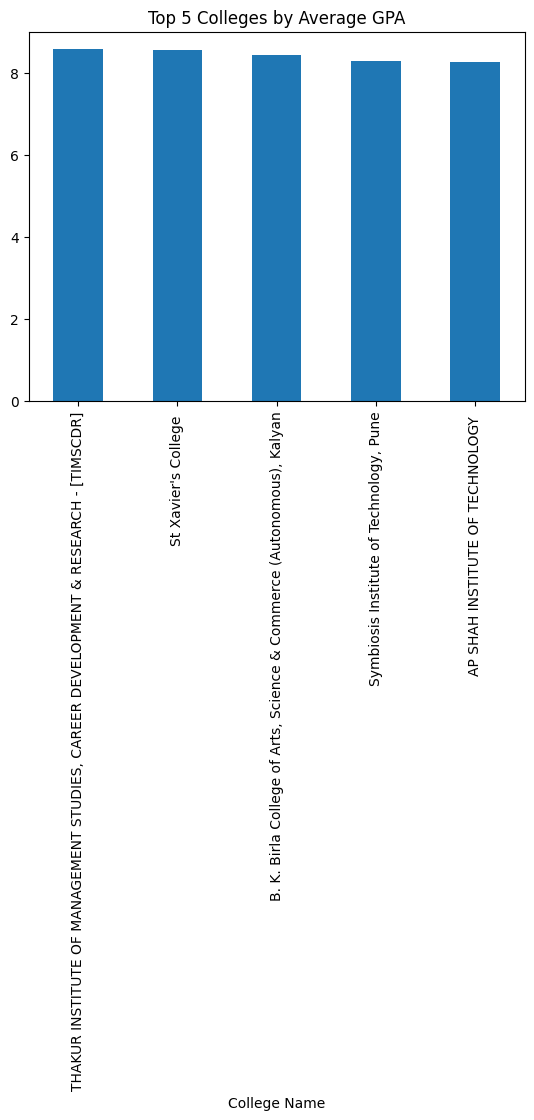

In [ ]:
college_gpa.plot(kind="bar", title="Top 5 Colleges by Average GPA")

Q7. Are there any outliers in the quantity (number of courses completed) attribute?

In [ ]:
df["Quantity"].describe()

,Quantity
count,4894.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


In [ ]:
Q1 = df["Quantity"].quantile(0.25)
Q3 = df["Quantity"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

lower_bound, upper_bound

(np.float64(1.0), np.float64(1.0))

In [ ]:
outliers = df[(df["Quantity"] < lower_bound) | (df["Quantity"] > upper_bound)]
outliers

,First Name,Email ID,Quantity,Events,Attendee Status,College Name,How did you come to know about this event?,"Specify in ""Others"" (how did you come to know about this event)",Designation,Year of Graduation,City,CGPA,Experience with python (Months),Family Income,Expected salary (Lac),Leadership- skills,Family_Income_Numeric


In [ ]:
outliers.shape[0]

0

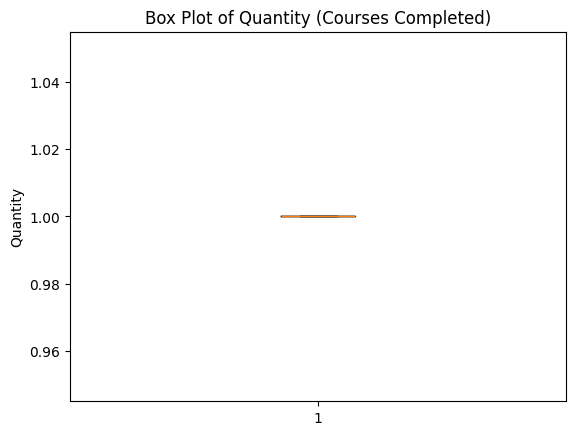

In [ ]:
import matplotlib.pyplot as plt

plt.boxplot(df["Quantity"])
plt.title("Box Plot of Quantity (Courses Completed)")
plt.ylabel("Quantity")
plt.show()

Q8. What is the average GPA for students from each city?

In [ ]:
import pandas as pd

In [ ]:
df["City"].isna().sum()

np.int64(0)

In [ ]:
df["City"] = df["City"].astype(str).str.strip()

In [ ]:
city_gpa = df.groupby("City")["CGPA"].mean()
city_gpa

,CGPA
City,
Agartala,7.660714
Agra,8.046429
Ahemdabad,8.190385
Ajmer,8.284314
Akola,8.021429
...,...
Vidisha,7.738095
Vijaywada,7.986364
Wardha,8.328571


Q9. What is the relationship between Family Income and GPA?

In [ ]:
income_mapping = {
    "0-2 Lakh": 1,
    "2-5 Lakh": 3.5,
    "5-7 Lakh": 6,
    "7 Lakh+": 8
}

df["Family_Income_Numeric"] = df["Family Income"].map(income_mapping)

In [ ]:
clean_df = df.dropna(subset=["Family_Income_Numeric", "CGPA"])

In [ ]:
correlation = clean_df["Family_Income_Numeric"].corr(clean_df["CGPA"])
correlation

np.float64(0.01574077700967218)

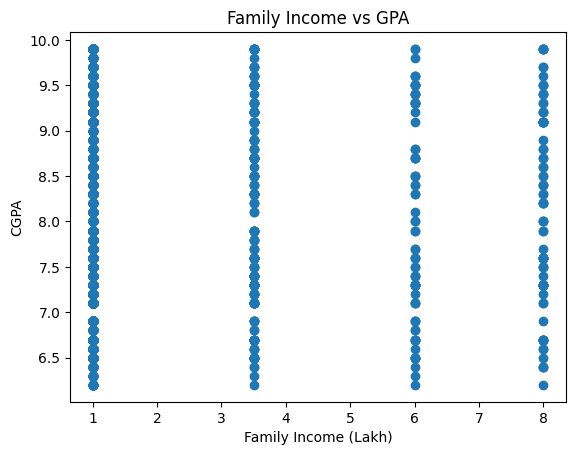

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(clean_df["Family_Income_Numeric"], clean_df["CGPA"])
plt.xlabel("Family Income (Lakh)")
plt.ylabel("CGPA")
plt.title("Family Income vs GPA")
plt.show()